# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Rayyan Muhtar Ali | 5054251051 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
https://www.kaggle.com/datasets/abbas829/bankruptcy

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


In [3]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
data = pd.read_csv('bankruptcy.csv')

# 95 dari 96 nama kolom di csv ini ada spasi di depannya, dirapikan dulu biar gak nyusahin waktu manggil kolom
data.columns = [kolom.strip() for kolom in data.columns]

print('jumlah baris dan kolom :', data.shape)
data.head()


jumlah baris dan kolom : (6819, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net Interest Rate 

In [5]:
# 96 kolom jadi describe-nya di-transpose biar kebaca
data.describe().T


,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


In [6]:
# cek missing value, duplikat, dan kolom yang isinya cuma satu nilai
print('total missing value :', data.isna().sum().sum())
print('jumlah baris duplikat :', data.duplicated().sum())
print()

jumlah_unik = data.nunique()
print('kolom konstan (cuma 1 nilai unik) :', list(jumlah_unik[jumlah_unik == 1].index))
print()
print('kolom yang tipenya bukan angka :', list(data.select_dtypes(exclude=[np.number]).columns))


total missing value : 0
jumlah baris duplikat : 0



kolom konstan (cuma 1 nilai unik) : ['Net Income Flag']

kolom yang tipenya bukan angka : []


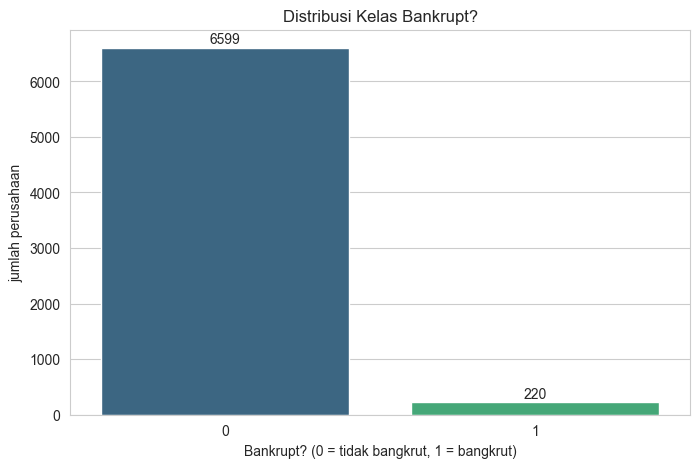

Bankrupt?
0    6599
1     220
Name: count, dtype: int64

proporsi tiap kelas (%) :
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64

rasio ketimpangan : 1 : 30.0


In [7]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
jumlah = data['Bankrupt?'].value_counts().sort_index()

ax = sns.barplot(x=jumlah.index, y=jumlah.values, hue=jumlah.index, palette='viridis', legend=False)
for i, v in enumerate(jumlah.values):
    ax.text(i, v + 80, str(v), ha='center')
plt.title('Distribusi Kelas Bankrupt?')
plt.xlabel('Bankrupt? (0 = tidak bangkrut, 1 = bangkrut)')
plt.ylabel('jumlah perusahaan')
plt.show()

print(jumlah)
print()
print('proporsi tiap kelas (%) :')
print((data['Bankrupt?'].value_counts(normalize=True).sort_index() * 100).round(2))
print()
print('rasio ketimpangan : 1 :', round(jumlah[0] / jumlah[1], 1))


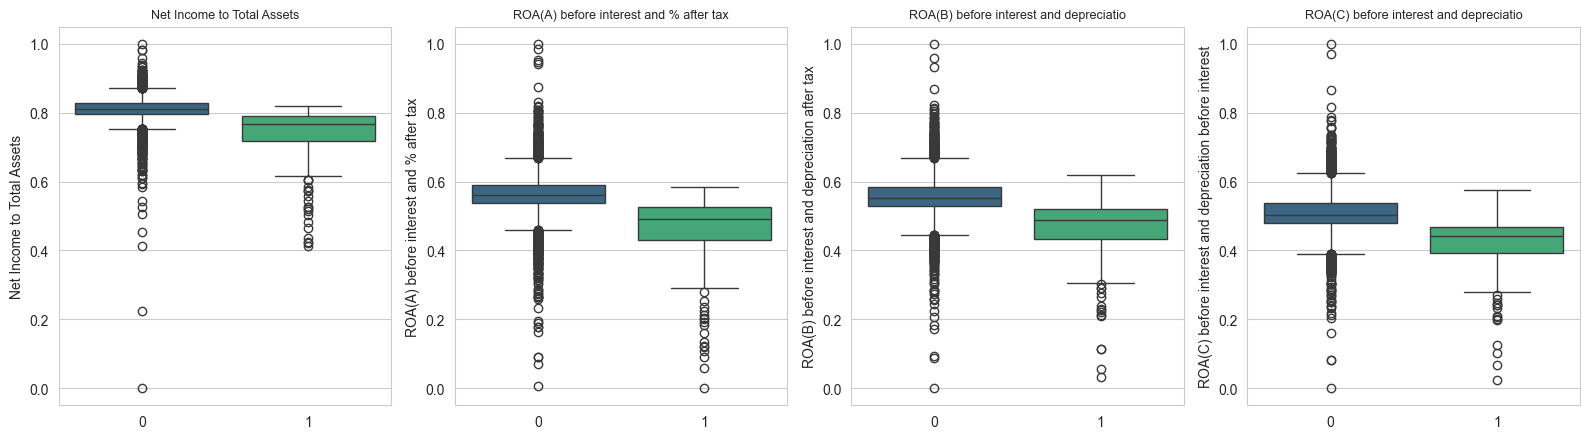

korelasi 4 fitur di atas ke Bankrupt? :
Net Income to Total Assets                                -0.3155
ROA(A) before interest and % after tax                    -0.2829
ROA(B) before interest and depreciation after tax         -0.2731
ROA(C) before interest and depreciation before interest   -0.2608
Name: Bankrupt?, dtype: float64


In [8]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
# ambil 4 fitur yang korelasinya paling kuat ke target, terus lihat sebarannya per kelas
korelasi_target = data.corr(numeric_only=True)['Bankrupt?'].drop('Bankrupt?')
fitur_kuat = korelasi_target.abs().sort_values(ascending=False).head(4).index

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, kolom in zip(axes, fitur_kuat):
    sns.boxplot(x='Bankrupt?', y=kolom, data=data, hue='Bankrupt?', palette='viridis', legend=False, ax=ax)
    ax.set_title(kolom[:38], fontsize=9)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

print('korelasi 4 fitur di atas ke Bankrupt? :')
print(korelasi_target[fitur_kuat].round(4))


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

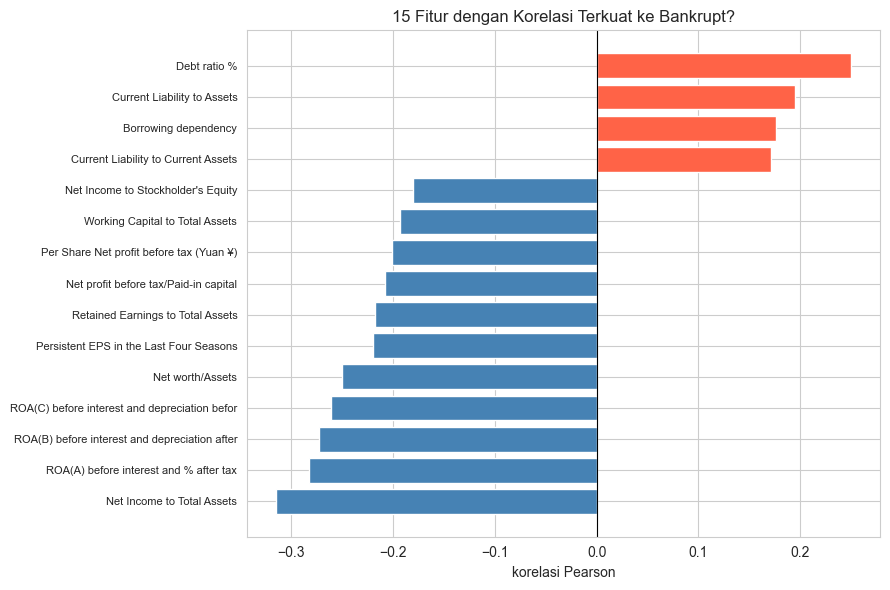

In [9]:
# 15 fitur dengan korelasi absolut paling besar ke target
top15 = korelasi_target.abs().sort_values(ascending=False).head(15)
urut = korelasi_target[top15.index].sort_values()

plt.figure(figsize=(9, 6))
warna = ['tomato' if v > 0 else 'steelblue' for v in urut.values]
plt.barh(range(len(urut)), urut.values, color=warna)
plt.yticks(range(len(urut)), [k[:45] for k in urut.index], fontsize=8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('15 Fitur dengan Korelasi Terkuat ke Bankrupt?')
plt.xlabel('korelasi Pearson')
plt.tight_layout()
plt.show()


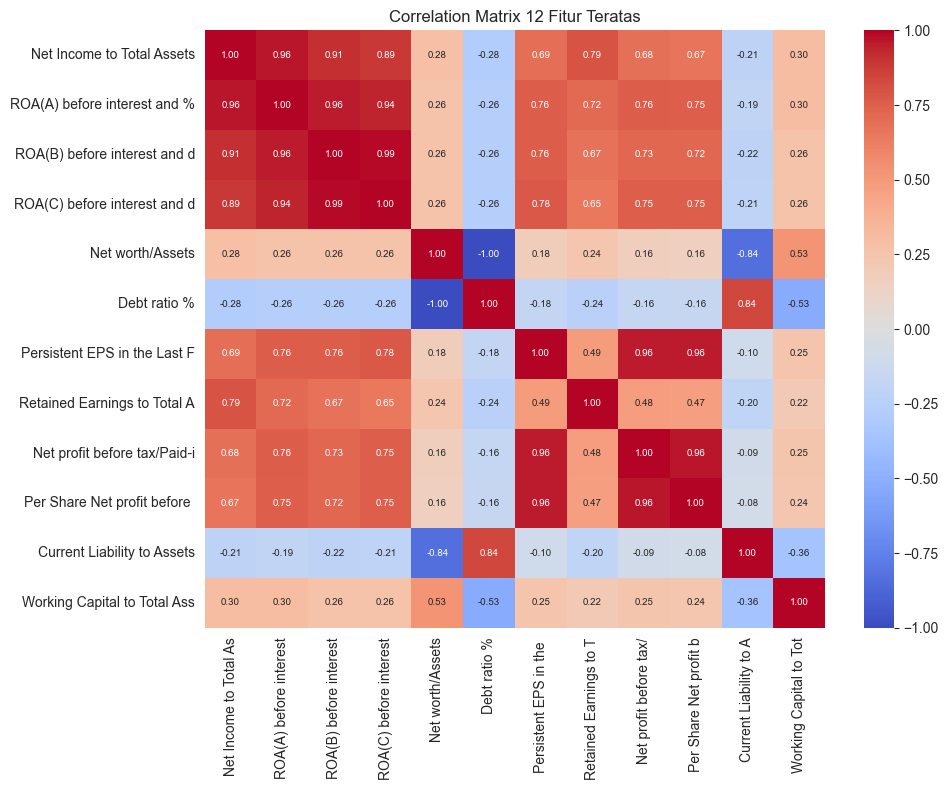

In [10]:
# korelasi antar 12 fitur teratas, buat lihat ada fitur yang saling tumpang tindih atau gak
top12 = list(korelasi_target.abs().sort_values(ascending=False).head(12).index)

plt.figure(figsize=(10, 8))
sns.heatmap(data[top12].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=[k[:22] for k in top12], yticklabels=[k[:28] for k in top12],
            annot_kws={'size': 7})
plt.title('Correlation Matrix 12 Fitur Teratas')
plt.tight_layout()
plt.show()


# 2. Preprocessing

In [11]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# dari pengecekan di bagian 1, dataset ini gak punya missing value sama sekali dan gak ada baris duplikat,
# jadi gak perlu imputasi apa pun. ini sekaligus paling aman soal data leakage, karena imputasi yang
# di-fit ke seluruh data sebelum split itu termasuk bocor.
print('missing value per kolom, diambil yang > 0 :')
print(data.isna().sum()[data.isna().sum() > 0])
print('(kosong berarti memang gak ada yang missing)')
print()

# Net Income Flag isinya 1 terus di semua baris, gak ada informasi yang bisa dipakai buat memisahkan kelas,
# jadi dibuang. kolom konstan gak mungkin jadi tempat split dan cuma nambah beban fitur.
df = data.drop(columns=['Net Income Flag'])

print('sebelum drop kolom konstan :', data.shape)
print('sesudah drop kolom konstan :', df.shape)


missing value per kolom, diambil yang > 0 :
Series([], dtype: int64)
(kosong berarti memang gak ada yang missing)

sebelum drop kolom konstan : (6819, 96)
sesudah drop kolom konstan : (6819, 95)


In [12]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.
# semua 95 fitur di dataset ini sudah berupa angka (rasio-rasio keuangan), jadi gak ada yang perlu di-encode.
# target Bankrupt? juga sudah 0/1 jadi gak butuh LabelEncoder.
print('jumlah kolom per tipe data :')
print(df.dtypes.value_counts())
print()
print('kolom bertipe object/kategorikal :', list(df.select_dtypes(include=['object', 'category']).columns))
print('nilai unik pada target :', sorted(df['Bankrupt?'].unique()))


jumlah kolom per tipe data :
float64    93
int64       2
Name: count, dtype: int64

kolom bertipe object/kategorikal : []
nilai unik pada target : [np.int64(0), np.int64(1)]


In [13]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=['Bankrupt?'])
y = df['Bankrupt?']

print('X :', X.shape)
print('y :', y.shape)
print()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('data train :', X_train.shape)
print('data test  :', X_test.shape)
print()
print('proporsi kelas train (%) :')
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))
print()
print('proporsi kelas test (%) :')
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))
print()
# stratify dipakai karena kelas 1 cuma 3.23%, kalau split-nya acak biasa proporsi bangkrut
# di test set gampang melenceng jauh dari data aslinya
print('jumlah kelas 1 di train :', (y_train == 1).sum(), '| di test :', (y_test == 1).sum())


X : (6819, 94)
y : (6819,)

data train : (5455, 94)
data test  : (1364, 94)

proporsi kelas train (%) :
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64

proporsi kelas test (%) :
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64

jumlah kelas 1 di train : 176 | di test : 44


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [14]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

print('kedalaman pohon :', dt_gini.get_depth())
print('jumlah leaf     :', dt_gini.get_n_leaves())
print('akurasi train   :', round(dt_gini.score(X_train, y_train), 4))
print('akurasi test    :', round(dt_gini.score(X_test, y_test), 4))


kedalaman pohon : 20
jumlah leaf     : 124
akurasi train   : 1.0
akurasi test    : 0.9611


In [15]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
pred_gini = dt_gini.predict(X_test)

print('10 prediksi pertama :', pred_gini[:10])
print('10 label asli       :', y_test.values[:10])
print()
print(classification_report(y_test, pred_gini, digits=4))


10 prediksi pertama : [0 0 0 0 0 0 0 0 0 0]
10 label asli       : [0 0 0 0 0 0 0 0 0 0]

              precision    recall  f1-score   support

           0     0.9796    0.9803    0.9799      1320
           1     0.3953    0.3864    0.3908        44

    accuracy                         0.9611      1364
   macro avg     0.6875    0.6833    0.6854      1364
weighted avg     0.9607    0.9611    0.9609      1364



## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [16]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
# hyperparameter lain dibiarkan sama persis dengan model gini (cuma criterion yang beda) biar perbandingannya adil
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

print('kedalaman pohon :', dt_entropy.get_depth())
print('jumlah leaf     :', dt_entropy.get_n_leaves())
print('akurasi train   :', round(dt_entropy.score(X_train, y_train), 4))
print('akurasi test    :', round(dt_entropy.score(X_test, y_test), 4))


kedalaman pohon : 18
jumlah leaf     : 101
akurasi train   : 1.0
akurasi test    : 0.9589


In [17]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
pred_entropy = dt_entropy.predict(X_test)

print('10 prediksi pertama :', pred_entropy[:10])
print('10 label asli       :', y_test.values[:10])
print()
print(classification_report(y_test, pred_entropy, digits=4))
print()
print('jumlah prediksi yang beda antara gini dan entropy :',
      (pred_gini != pred_entropy).sum(), 'dari', len(pred_gini))


10 prediksi pertama : [0 0 0 0 0 0 0 0 0 0]
10 label asli       : [0 0 0 0 0 0 0 0 0 0]

              precision    recall  f1-score   support

           0     0.9781    0.9795    0.9788      1320
           1     0.3571    0.3409    0.3488        44

    accuracy                         0.9589      1364
   macro avg     0.6676    0.6602    0.6638      1364
weighted avg     0.9580    0.9589    0.9585      1364


jumlah prediksi yang beda antara gini dan entropy : 59 dari 1364


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [18]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
# kriteria yang dipakai gini, soalnya di 3.1 dan 3.2 tadi gini sedikit lebih bagus dari entropy
# (f1 kelas 1 0.3908 lawan 0.3488), jadi eksperimen max_depth ini dijalankan di atas gini
list_depth = [1, 2, 3, 5, 10, None]

model_depth = {}
for d in list_depth:
    model = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    model_depth[d] = model
    print('max_depth =', str(d).ljust(5), '-> kedalaman asli :', str(model.get_depth()).ljust(3),
          '| jumlah leaf :', model.get_n_leaves())


max_depth = 1     -> kedalaman asli : 1   | jumlah leaf : 2


max_depth = 2     -> kedalaman asli : 2   | jumlah leaf : 4


max_depth = 3     -> kedalaman asli : 3   | jumlah leaf : 8


max_depth = 5     -> kedalaman asli : 5   | jumlah leaf : 21


max_depth = 10    -> kedalaman asli : 10  | jumlah leaf : 88


max_depth = None  -> kedalaman asli : 20  | jumlah leaf : 124


In [19]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
hasil_depth = []
for d, model in model_depth.items():
    p_train = model.predict(X_train)
    p_test = model.predict(X_test)
    hasil_depth.append({
        'max_depth': 'None' if d is None else d,
        'kedalaman_asli': model.get_depth(),
        'jumlah_leaf': model.get_n_leaves(),
        'akurasi_train': accuracy_score(y_train, p_train),
        'akurasi_test': accuracy_score(y_test, p_test),
        'recall_kelas1_test': recall_score(y_test, p_test, pos_label=1, zero_division=0),
        'f1_kelas1_test': f1_score(y_test, p_test, pos_label=1, zero_division=0),
    })

hasil_depth = pd.DataFrame(hasil_depth)
hasil_depth['selisih_train_test'] = hasil_depth['akurasi_train'] - hasil_depth['akurasi_test']
hasil_depth.round(4)


,max_depth,kedalaman_asli,jumlah_leaf,akurasi_train,akurasi_test,recall_kelas1_test,f1_kelas1_test,selisih_train_test
0,1,1,2,0.9677,0.9677,0.0000,0.0000,-0.0000
1,2,2,4,0.9699,0.9699,0.0909,0.1633,-0.0000
2,3,3,8,0.9723,0.9714,0.2045,0.3158,0.0009
3,5,5,21,0.9775,0.9692,0.4091,0.4615,0.0082
4,10,10,88,0.9947,0.9611,0.3636,0.3765,0.0335
5,None,20,124,1.0000,0.9611,0.3864,0.3908,0.0389


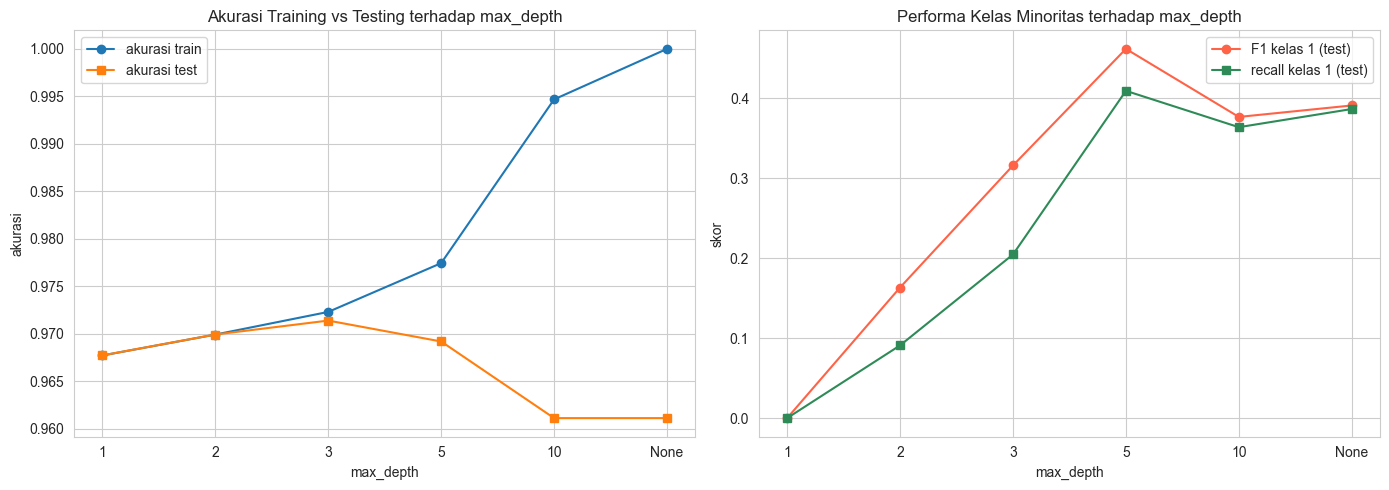

selisih akurasi train - test per max_depth :
max_depth  akurasi_train  akurasi_test  selisih_train_test
        1         0.9677        0.9677             -0.0000
        2         0.9699        0.9699             -0.0000
        3         0.9723        0.9714              0.0009
        5         0.9775        0.9692              0.0082
       10         0.9947        0.9611              0.0335
     None         1.0000        0.9611              0.0389


In [20]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
label_x = hasil_depth['max_depth'].astype(str)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(label_x, hasil_depth['akurasi_train'], marker='o', label='akurasi train')
ax[0].plot(label_x, hasil_depth['akurasi_test'], marker='s', label='akurasi test')
ax[0].set_title('Akurasi Training vs Testing terhadap max_depth')
ax[0].set_xlabel('max_depth')
ax[0].set_ylabel('akurasi')
ax[0].legend()

# akurasi doang nyamarin masalahnya karena datanya timpang, jadi f1 dan recall kelas 1 diplot terpisah
ax[1].plot(label_x, hasil_depth['f1_kelas1_test'], marker='o', color='tomato', label='F1 kelas 1 (test)')
ax[1].plot(label_x, hasil_depth['recall_kelas1_test'], marker='s', color='seagreen', label='recall kelas 1 (test)')
ax[1].set_title('Performa Kelas Minoritas terhadap max_depth')
ax[1].set_xlabel('max_depth')
ax[1].set_ylabel('skor')
ax[1].legend()

plt.tight_layout()
plt.show()

print('selisih akurasi train - test per max_depth :')
print(hasil_depth[['max_depth', 'akurasi_train', 'akurasi_test', 'selisih_train_test']].round(4).to_string(index=False))


# 4. Evaluasi Model

In [21]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def ringkas_metrik(nama, y_asli, y_pred):
    return {
        'model': nama,
        'accuracy': accuracy_score(y_asli, y_pred),
        'precision_kelas1': precision_score(y_asli, y_pred, pos_label=1, zero_division=0),
        'recall_kelas1': recall_score(y_asli, y_pred, pos_label=1, zero_division=0),
        'f1_kelas1': f1_score(y_asli, y_pred, pos_label=1, zero_division=0),
        'precision_macro': precision_score(y_asli, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_asli, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_asli, y_pred, average='macro', zero_division=0),
    }


perbandingan = pd.DataFrame([
    ringkas_metrik('Gini', y_test, pred_gini),
    ringkas_metrik('Entropy', y_test, pred_entropy),
])

# kalau semua ditebak "tidak bangkrut" akurasinya sudah setinggi ini, jadi angka accuracy perlu dibandingin ke sini
baseline = (y_test == 0).mean()
print('baseline tebak kelas mayoritas terus, akurasinya :', round(baseline, 4))
print()
perbandingan.set_index('model').round(4)


baseline tebak kelas mayoritas terus, akurasinya : 0.9677



,accuracy,precision_kelas1,recall_kelas1,f1_kelas1,precision_macro,recall_macro,f1_macro
model,,,,,,,
Gini,0.9611,0.3953,0.3864,0.3908,0.6875,0.6833,0.6854
Entropy,0.9589,0.3571,0.3409,0.3488,0.6676,0.6602,0.6638


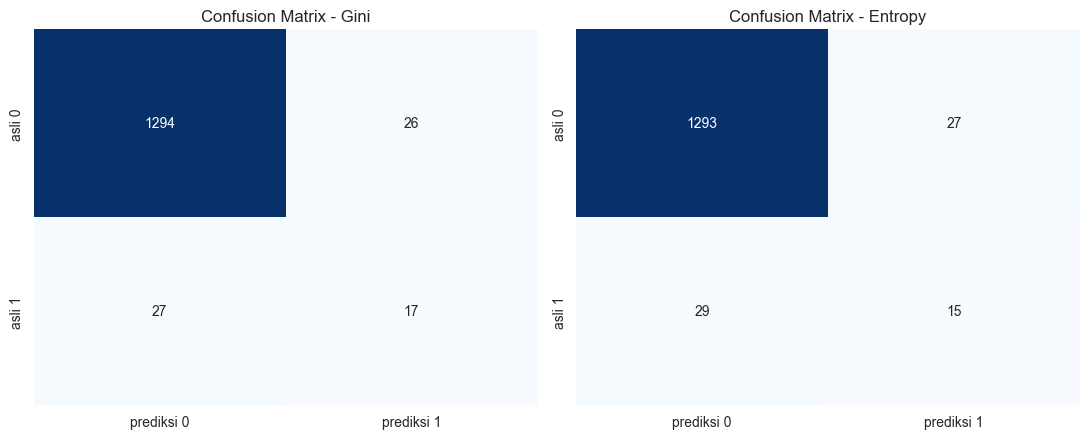

Gini     -> TN = 1294 | FP = 26 | FN = 27 | TP = 17 | dari 44 perusahaan bangkrut di test set, kekenali 17
Entropy  -> TN = 1293 | FP = 27 | FN = 29 | TP = 15 | dari 44 perusahaan bangkrut di test set, kekenali 15


In [22]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (nama, pred) in zip(axes, [('Gini', pred_gini), ('Entropy', pred_entropy)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['prediksi 0', 'prediksi 1'], yticklabels=['asli 0', 'asli 1'])
    ax.set_title('Confusion Matrix - ' + nama)
plt.tight_layout()
plt.show()

for nama, pred in [('Gini', pred_gini), ('Entropy', pred_entropy)]:
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(nama.ljust(8), '-> TN =', tn, '| FP =', fp, '| FN =', fn, '| TP =', tp,
          '| dari', tp + fn, 'perusahaan bangkrut di test set, kekenali', tp)


model terbaik : gini, max_depth = 5 | f1 kelas 1 : 0.4615

              precision    recall  f1-score   support

           0     0.9805    0.9879    0.9842      1320
           1     0.5294    0.4091    0.4615        44

    accuracy                         0.9692      1364
   macro avg     0.7549    0.6985    0.7228      1364
weighted avg     0.9659    0.9692    0.9673      1364

TN = 1304 | FP = 16 | FN = 26 | TP = 18 | kekenali 18 dari 44 perusahaan bangkrut



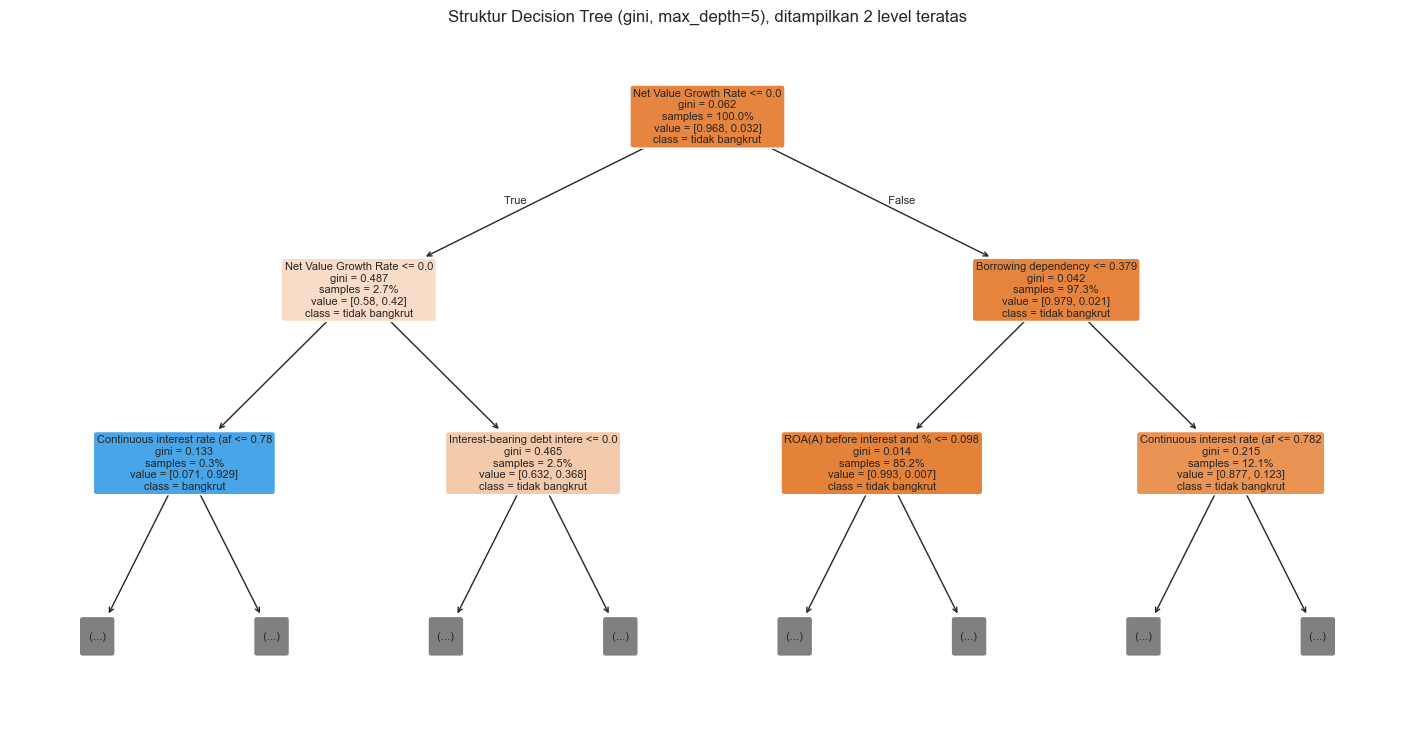

In [23]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.
# model terbaik dipilih dari f1 kelas 1, bukan dari accuracy, karena accuracy di data timpang begini gak informatif
baris_terbaik = hasil_depth.loc[hasil_depth['f1_kelas1_test'].idxmax()]
depth_terbaik = None if baris_terbaik['max_depth'] == 'None' else int(baris_terbaik['max_depth'])
model_terbaik = model_depth[depth_terbaik]

print('model terbaik : gini, max_depth =', baris_terbaik['max_depth'],
      '| f1 kelas 1 :', round(baris_terbaik['f1_kelas1_test'], 4))
print()

# sekalian lihat rincian metriknya dibanding pohon yang dibiarkan tumbuh penuh di bagian 3
pred_terbaik = model_terbaik.predict(X_test)
print(classification_report(y_test, pred_terbaik, digits=4))
tn, fp, fn, tp = confusion_matrix(y_test, pred_terbaik).ravel()
print('TN =', tn, '| FP =', fp, '| FN =', fn, '| TP =', tp,
      '| kekenali', tp, 'dari', tp + fn, 'perusahaan bangkrut')
print()

plt.figure(figsize=(18, 9))
plot_tree(model_terbaik, max_depth=2, feature_names=[k[:28] for k in X.columns],
          class_names=['tidak bangkrut', 'bangkrut'], filled=True, rounded=True,
          fontsize=8, proportion=True)
plt.title('Struktur Decision Tree (gini, max_depth=' + str(baris_terbaik['max_depth']) +
          '), ditampilkan 2 level teratas')
plt.show()


jumlah fitur yang benar-benar dipakai pohon : 16 dari 94



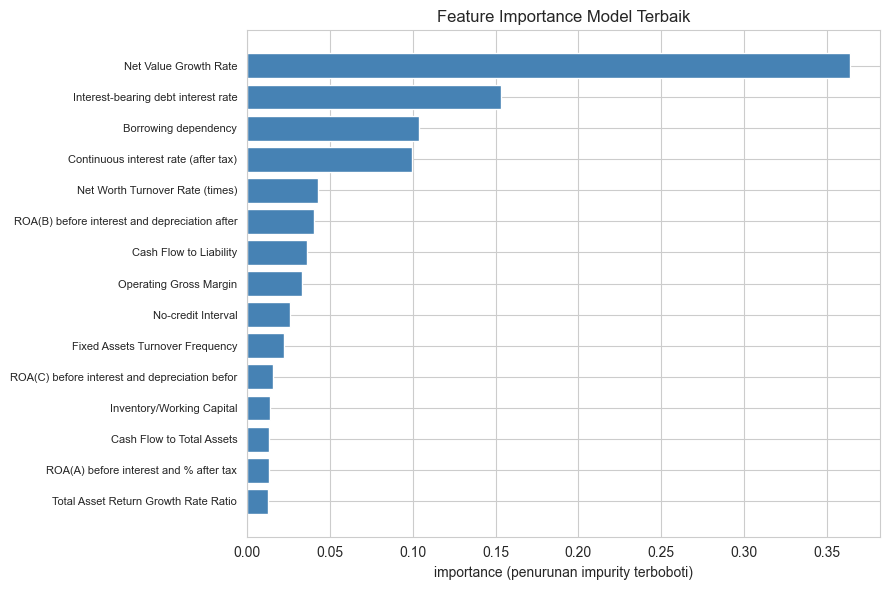

Net Value Growth Rate                                0.3639
Interest-bearing debt interest rate                  0.1530
Borrowing dependency                                 0.1038
Continuous interest rate (after tax)                 0.0999
Net Worth Turnover Rate (times)                      0.0430
ROA(B) before interest and depreciation after tax    0.0402
Cash Flow to Liability                               0.0364
Operating Gross Margin                               0.0331
No-credit Interval                                   0.0257
Fixed Assets Turnover Frequency                      0.0221
dtype: float64


In [24]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.
penting = pd.Series(model_terbaik.feature_importances_, index=X.columns)
penting = penting[penting > 0].sort_values(ascending=False)

print('jumlah fitur yang benar-benar dipakai pohon :', len(penting), 'dari', X.shape[1])
print()

top = penting.head(15).sort_values()
plt.figure(figsize=(9, 6))
plt.barh(range(len(top)), top.values, color='steelblue')
plt.yticks(range(len(top)), [k[:45] for k in top.index], fontsize=8)
plt.title('Feature Importance Model Terbaik')
plt.xlabel('importance (penurunan impurity terboboti)')
plt.tight_layout()
plt.show()

print(penting.head(10).round(4))


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

Sebelum masuk ke perbandingan model, yang paling menentukan di dataset ini adalah ketimpangan kelasnya. Dari 6819 perusahaan, cuma 220 yang bangkrut (3.23%), perbandingannya sekitar 1 : 30. Efeknya, kalau semua data ditebak "tidak bangkrut" terus, akurasinya sudah 0.9677 tanpa model belajar apa pun. Jadi sepanjang analisis ini saya gak terlalu pakai accuracy sebagai patokan, dan lebih lihat precision, recall, dan F1 di kelas 1.

**Gini vs Entropy.** Selisihnya kecil sekali. Akurasi test gini 0.9611 dan entropy 0.9589, bedanya 0.0022 yang kalau dihitung cuma sekitar 3 baris dari 1364 data test. Di kelas 1 gini memang lebih bagus (F1 0.3908 lawan 0.3488, recall 0.3864 lawan 0.3409), tapi bedanya juga tipis: dari 44 perusahaan bangkrut di test set, gini kekenali 17 dan entropy 15, jadi selisihnya cuma 2 perusahaan. Dari 1364 prediksi, yang benar-benar beda antara kedua model cuma 59 (4.3%). Menurut saya ini wajar, karena Gini Impurity dan Entropy sama-sama mengukur seberapa campur isi sebuah node dan nilainya bergerak dengan pola yang mirip, cuma skalanya beda. Keduanya jadi hampir selalu memilih split yang sama, apalagi di sini fiturnya 94 dan semuanya kontinu, jadi kandidat threshold-nya banyak dan banyak yang kualitasnya nyaris setara. Yang lebih kelihatan bedanya justru bentuk pohonnya: gini tumbuh sampai kedalaman 20 dengan 124 leaf, entropy 18 dengan 101 leaf. Dan dua-duanya akurasi train-nya 1.0000, artinya sama-sama hafal data training.

**Eksperimen max_depth.** Ini yang pengaruhnya jauh lebih besar daripada pilihan kriteria. Di `max_depth=1` pohonnya cuma punya 2 leaf dan recall kelas 1-nya 0, artinya semua data diprediksi tidak bangkrut, dan akurasinya 0.9677 persis sama dengan baseline tadi. Ini contoh bagus kenapa akurasi tinggi gak selalu berarti modelnya berguna. Di `max_depth=2` recall-nya baru 0.0909 (4 dari 44), lalu naik terus sampai puncaknya di `max_depth=5` dengan F1 kelas 1 0.4615 dan recall 0.4091.

Gejala overfitting-nya mulai kelihatan setelah `max_depth=5`. Cirinya jelas dari selisih akurasi train dan test: di depth 1 sampai 3 selisihnya nol atau malah sedikit negatif (-0.0000, -0.0000, 0.0009), di depth 5 mulai positif kecil 0.0082, lalu melonjak jadi 0.0335 di depth 10 dan 0.0389 waktu kedalamannya dibiarkan bebas. Di grafik, kurva akurasi training naik terus sampai menyentuh 1.0000 sementara kurva testing berhenti naik setelah depth 3 (puncaknya 0.9714) dan habis itu turun ke 0.9611. Jadi pohon yang tumbuh penuh cuma nambah hafalan, bukan nambah kemampuan generalisasi. Yang menarik, dua metrik ini gak sepakat soal model terbaik: kalau pakai akurasi test yang terbaik `max_depth=3`, tapi kalau pakai F1 kelas 1 yang terbaik `max_depth=5`. Saya pilih depth 5 karena tujuan kasus ini mendeteksi perusahaan yang bangkrut, dan di depth 3 recall-nya cuma 0.2045.

**Feature importance.** Model terbaik cuma memakai 16 dari 94 fitur, sisanya importance-nya 0. Empat teratas: `Net Value Growth Rate` (0.3639), `Interest-bearing debt interest rate` (0.1530), `Borrowing dependency` (0.1038), dan `Continuous interest rate (after tax)` (0.0999). Empat fitur ini saja sudah menyumbang sekitar 72% dari total importance, dan `Net Value Growth Rate` dipakai sebagai split paling atas dengan threshold `<= 0.0004`.

Yang bikin saya agak kaget, fitur-fitur ini bukan yang korelasinya paling kuat ke target. `Net Value Growth Rate` korelasinya cuma +0.0653 dan cuma peringkat 47 dari 94, `Continuous interest rate (after tax)` malah peringkat 75 dengan korelasi -0.0084. Sebaliknya `Net Income to Total Assets` yang korelasinya paling kuat (-0.3155) sama sekali gak dipakai oleh pohon terbaik ini. Setelah saya pikir, ini masuk akal karena korelasi Pearson cuma mengukur hubungan lurus satu fitur terhadap target secara sendirian, sedangkan Decision Tree memilih split yang paling memurnikan node *setelah* split-split sebelumnya. Jadi fitur yang trennya gak lurus tapi punya satu titik potong tajam bisa sangat berguna buat pohon walaupun korelasinya kecil. Ditambah lagi rasio-rasio keuangan di dataset ini banyak yang saling berkorelasi, jadi begitu satu fitur dipakai, fitur lain yang informasinya mirip jadi gak nambah apa-apa.

Satu hal yang perlu saya catat, semua angka di kelas 1 ini dasarnya cuma 44 baris di test set. Satu perusahaan saja berubah prediksi, recall-nya sudah gerak sekitar 0.023. Jadi selisih-selisih kecil seperti gini lawan entropy tadi sebaiknya jangan dianggap bukti kuat.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Model terbaik yang saya dapat adalah Decision Tree dengan kriteria **gini** dan **`max_depth=5`**, hasilnya akurasi test 0.9692, precision kelas 1 0.5294, recall kelas 1 0.4091, F1 kelas 1 0.4615, dan F1 macro 0.7228. Dari 44 perusahaan bangkrut di test set, model ini mengenali 18 dengan 16 false positive. Dibandingkan pohon yang dibiarkan tumbuh penuh (akurasi 0.9611, F1 kelas 1 0.3908, kekenali 17 dengan 26 false positive), membatasi kedalaman ternyata menang di semua sisi sekaligus bikin modelnya jauh lebih sederhana, 21 leaf lawan 124 leaf.

Dari dua hal yang diuji di tugas ini, pilihan kriteria split hampir gak ngaruh sedangkan regularisasi `max_depth` ngaruh besar. Tapi kesimpulan yang menurut saya paling penting justru soal metriknya: akurasi 0.9692 kedengarannya bagus, padahal cuma lebih tinggi 0.0015 dari baseline menebak "tidak bangkrut" untuk semua data. Model ini masih gagal mendeteksi 26 dari 44 perusahaan yang benar-benar bangkrut. Ini mirip temuan saya di tugas KNN sebelumnya, di data yang timpang, melihat accuracy saja bisa menyesatkan.

Sarannya:
1. Pemilihan `max_depth` sebaiknya jangan dari akurasi test seperti yang saya lakukan, karena test set jadi ikut dipakai buat memilih hyperparameter. Lebih baik pakai stratified k-fold cross validation, apalagi kelas 1 di test set cuma 44 baris jadi hasilnya gampang goyang.
2. Coba pruning pakai `ccp_alpha` (cost complexity pruning) sebagai pengganti menebak-nebak `max_depth`, dan `min_samples_leaf` supaya leaf yang isinya cuma beberapa baris gak kebentuk.
3. Ketimpangan kelasnya perlu ditangani langsung, misalnya `class_weight='balanced'` atau oversampling SMOTE. Sekarang pohonnya kurang termotivasi mengenali kelas 1 karena salah di kelas minoritas hukumannya kecil.
4. Kalau tujuannya memaksimalkan deteksi kebangkrutan, threshold keputusannya bisa digeser pakai `predict_proba` daripada pakai 0.5 begitu saja, supaya recall bisa dinaikkan dengan konsekuensi precision turun. Untuk kasus kebangkrutan, kelewat mendeteksi biasanya lebih murah daripada kelewat melewatkan.
5. Hasil ini sebaiknya dibandingkan dengan model ensemble seperti Random Forest atau Gradient Boosting, biar tahu batas 0.4615 ini keterbatasan datanya atau keterbatasan satu pohon tunggal.